# **Providing data-driven suggestions for HR**

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize with the HR dataset

The dataset contains 15,000 rows and 10 columns for the variables listed below.


Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import pandas as pd

# Path setup
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_preprocessing import clean_hr_data

# Load raw data
df0 = pd.read_csv('../data/HR_capstone_dataset.csv')

# Apply the cleaning logic
df = clean_hr_data(df0)

# Verify the changes
print(df.columns)
print(f"Shape after removing duplicates: {df.shape}")

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'Work_accident', 'left',
       'promotion_last_5years', 'department', 'salary', 'overworked'],
      dtype='str')
Shape after removing duplicates: (11991, 11)


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [2]:
# Gather basic information about the data

df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Gather descriptive statistics about the data

In [3]:
# Gather descriptive statistics about the data

df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [4]:
# Display all column names

df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [5]:
# Rename columns as needed

df0 = df0.rename(columns={'average_montly_hours': 'average_monthly_hours',
                          'Work_accident': 'work_accident',
                          'Department': 'department'})

# Display all column names after the update

print(df0.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')


### Check missing values

Check for any missing values in the data.

In [6]:
# Check for missing values

df0.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [7]:
# Check for duplicates

df0.duplicated().sum()

np.int64(3008)

In [8]:
# Drop duplicates and save resulting dataframe in a new variable as needed

df1 = df0.drop_duplicates()

# Display first few rows of new dataframe as needed

print(df1.head())
print(f"Shape after dropping duplicates: {df1.shape}")

   satisfaction_level  last_evaluation  number_project  average_monthly_hours  \
0                0.38             0.53               2                    157   
1                0.80             0.86               5                    262   
2                0.11             0.88               7                    272   
3                0.72             0.87               5                    223   
4                0.37             0.52               2                    159   

   time_spend_company  work_accident  left  promotion_last_5years department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  mediu

### Check outliers

Check for outliers in the data.

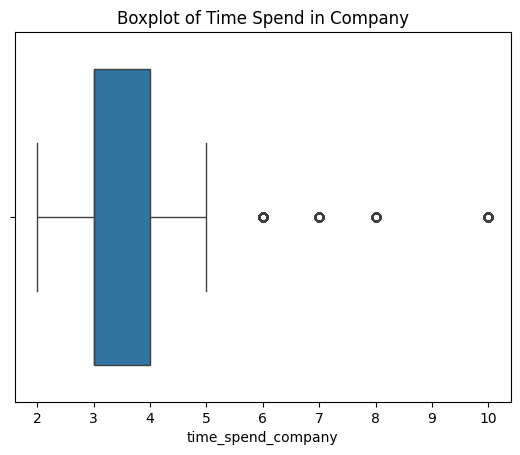

In [9]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

sns.boxplot(x=df1['time_spend_company'])
plt.title('Boxplot of Time Spend in Company')
plt.show()

In [10]:
# Determine the number of rows containing outliers

Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds for outliers
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Count outliers
outliers_count = df1[(df1['time_spend_company'] < lower_bound) | (df1['time_spend_company'] > upper_bound)].shape[0]
print(f"Number of rows with outliers in 'time_spend_company': {outliers_count}")

Number of rows with outliers in 'time_spend_company': 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [11]:
# Get numbers of people who left vs. stayed

print("Number of employees who left vs. stayed:")
print(df1['left'].value_counts())

# Get percentages of people who left vs. stayed

print("\nPercentage of employees who left vs. stayed:")
print(df1['left'].value_counts(normalize=True) * 100)

Number of employees who left vs. stayed:
left
0    10000
1     1991
Name: count, dtype: int64

Percentage of employees who left vs. stayed:
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

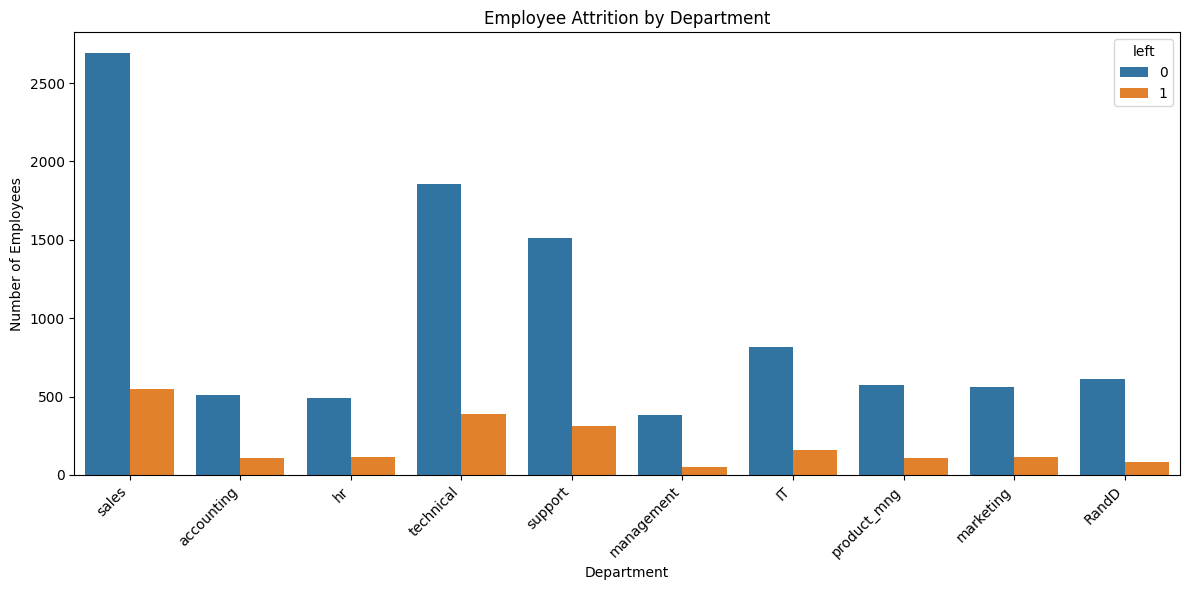

In [12]:
# Create a plot to visualize the number of employees who left by department
plt.figure(figsize=(12, 6))
sns.countplot(x='department', hue='left', data=df1)
plt.title('Employee Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

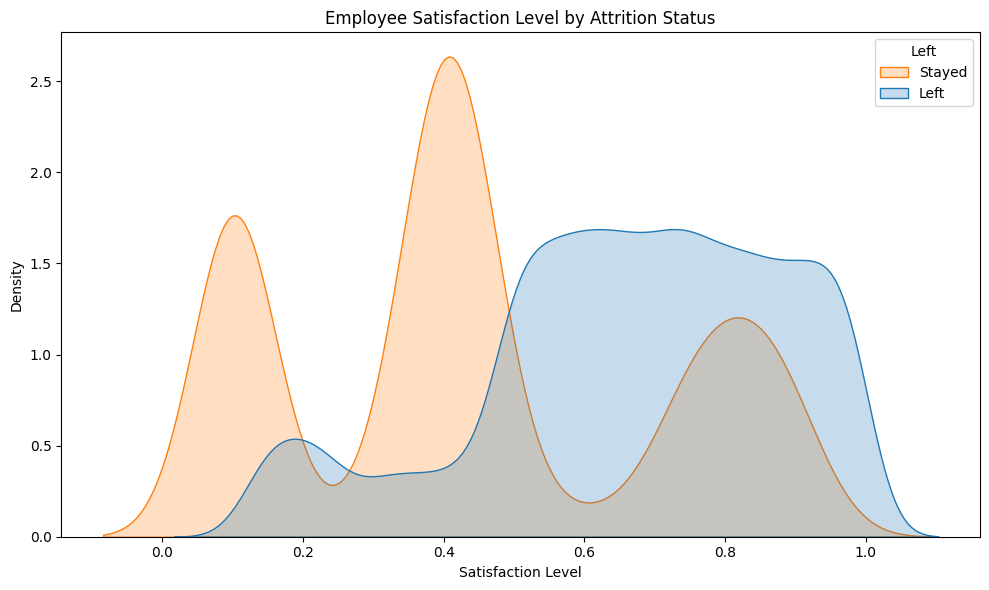

In [13]:
# Create a plot to visualize the relationship between 'satisfaction_level' and 'left'
plt.figure(figsize=(10, 6))
sns.kdeplot(x='satisfaction_level', hue='left', data=df1, fill=True, common_norm=False)
plt.title('Employee Satisfaction Level by Attrition Status')
plt.xlabel('Satisfaction Level')
plt.ylabel('Density')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

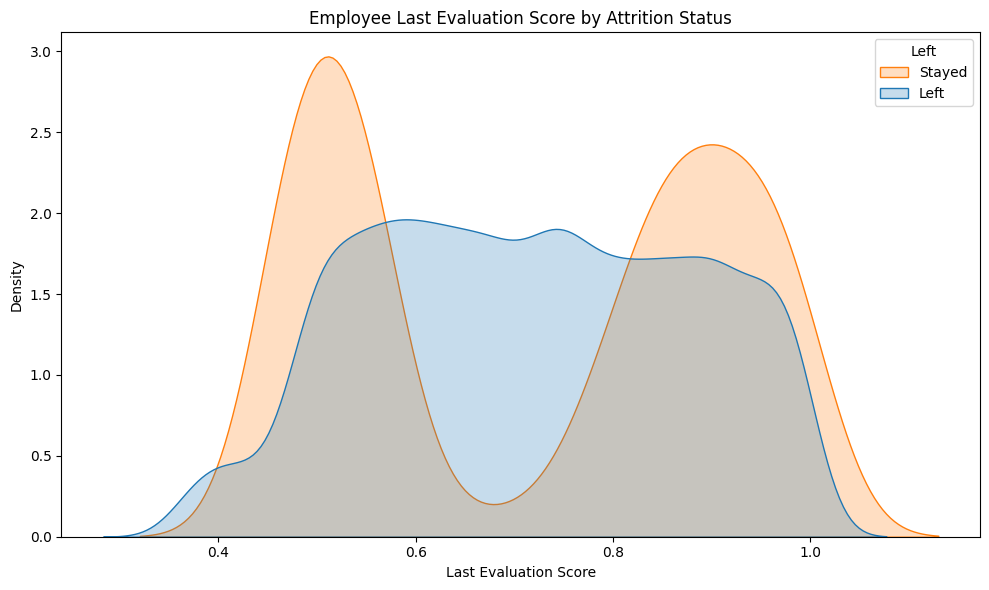

In [14]:
# Create a plot to visualize the relationship between 'last_evaluation' and 'left'
plt.figure(figsize=(10, 6))
sns.kdeplot(x='last_evaluation', hue='left', data=df1, fill=True, common_norm=False)
plt.title('Employee Last Evaluation Score by Attrition Status')
plt.xlabel('Last Evaluation Score')
plt.ylabel('Density')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

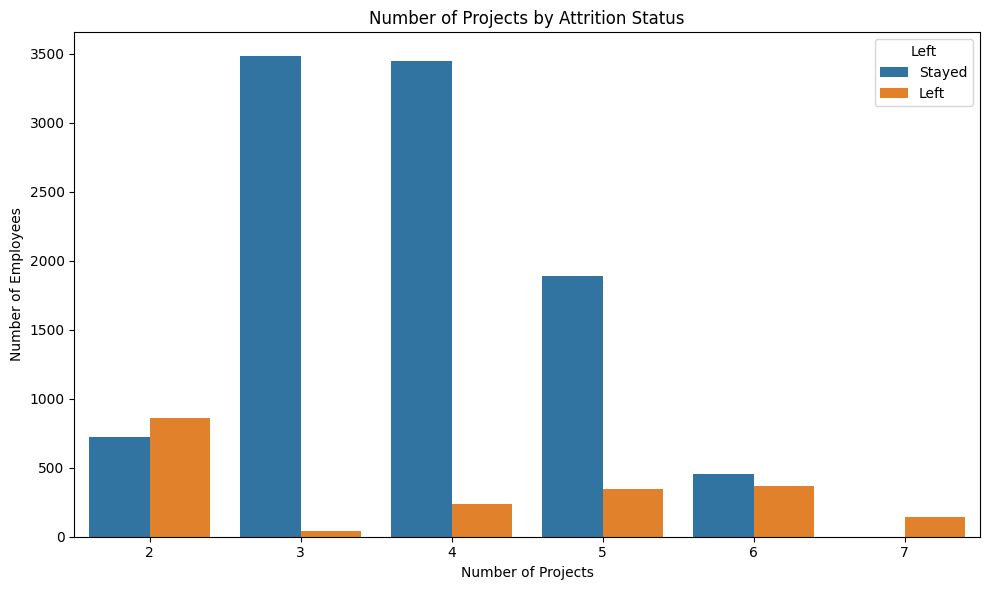

In [15]:
# Create a plot to visualize the relationship between 'number_project' and 'left'
plt.figure(figsize=(10, 6))
sns.countplot(x='number_project', hue='left', data=df1)
plt.title('Number of Projects by Attrition Status')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

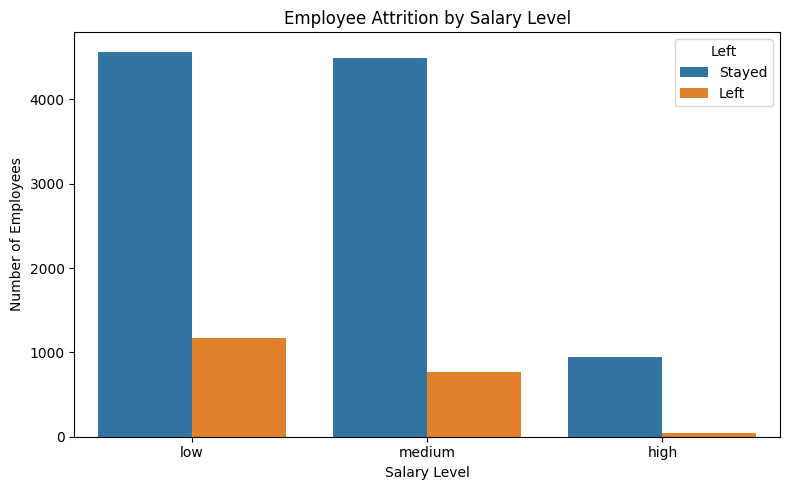

In [16]:
# Create a plot to visualize the relationship between 'salary' and 'left'
plt.figure(figsize=(8, 5))
sns.countplot(x='salary', hue='left', data=df1, order=['low', 'medium', 'high'])
plt.title('Employee Attrition by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

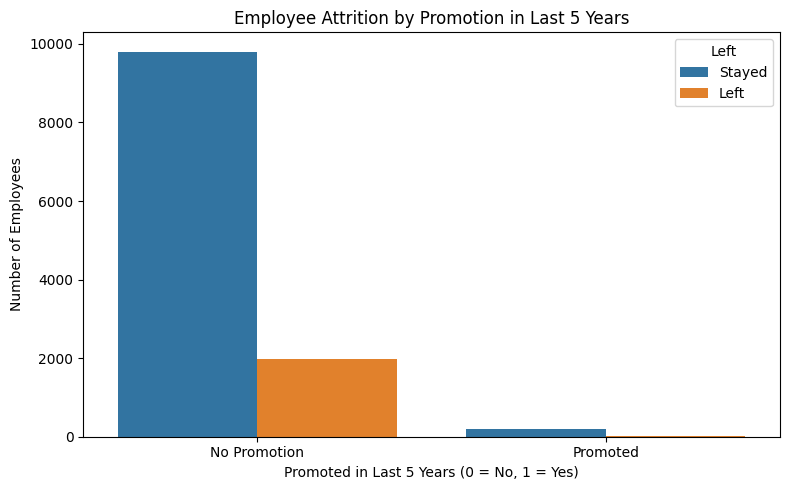

In [17]:
# Create a plot to visualize the relationship between 'promotion_last_5years' and 'left'
plt.figure(figsize=(8, 5))
sns.countplot(x='promotion_last_5years', hue='left', data=df1)
plt.title('Employee Attrition by Promotion in Last 5 Years')
plt.xlabel('Promoted in Last 5 Years (0 = No, 1 = Yes)')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.xticks(ticks=[0, 1], labels=['No Promotion', 'Promoted'])
plt.tight_layout()
plt.show()

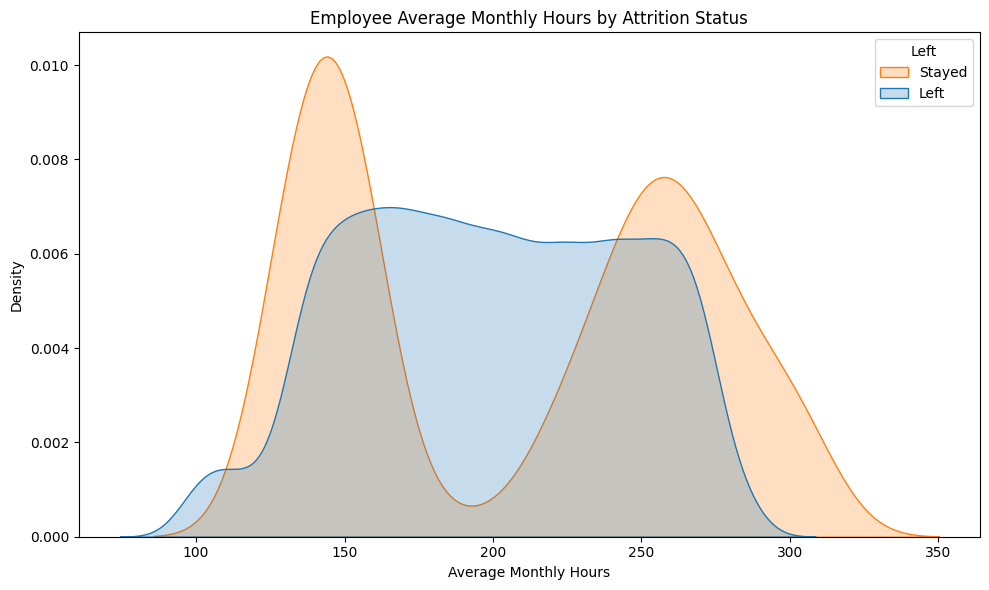

In [18]:
# Create a plot to visualize the relationship between 'average_monthly_hours' and 'left'
plt.figure(figsize=(10, 6))
sns.kdeplot(x='average_monthly_hours', hue='left', data=df1, fill=True, common_norm=False)
plt.title('Employee Average Monthly Hours by Attrition Status')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Density')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

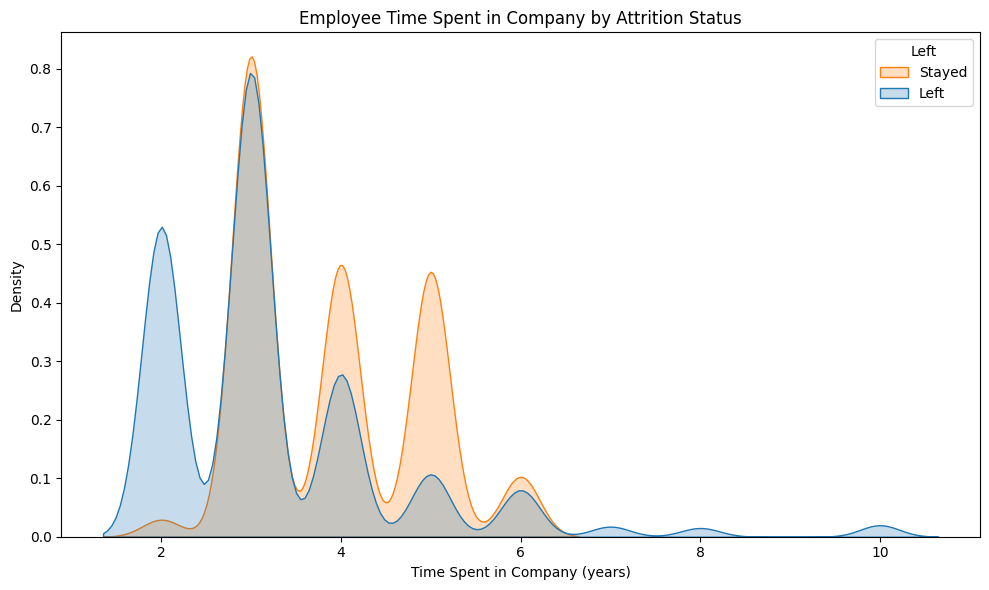

In [19]:
# Create a plot to visualize the relationship between 'time_spend_company' and 'left'
plt.figure(figsize=(10, 6))
sns.kdeplot(x='time_spend_company', hue='left', data=df1, fill=True, common_norm=False)
plt.title('Employee Time Spent in Company by Attrition Status')
plt.xlabel('Time Spent in Company (years)')
plt.ylabel('Density')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.tight_layout()
plt.show()

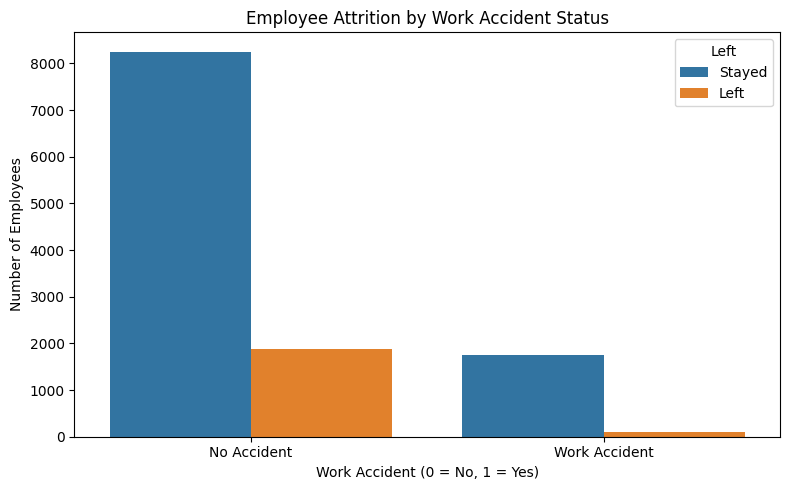

In [20]:
# Create a plot to visualize the relationship between 'work_accident' and 'left'
plt.figure(figsize=(8, 5))
sns.countplot(x='work_accident', hue='left', data=df1)
plt.title('Employee Attrition by Work Accident Status')
plt.xlabel('Work Accident (0 = No, 1 = Yes)')
plt.ylabel('Number of Employees')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.xticks(ticks=[0, 1], labels=['No Accident', 'Work Accident'])
plt.tight_layout()
plt.show()

### Insights

Here's a summary of the key insights we've gathered from the visualizations:

* **Employee Attrition Rate**: Approximately 16.6% of employees left the company,
indicating a significant retention challenge.
* **Attrition by Department**: Departments like 'sales' and 'technical' have the highest absolute numbers of employees leaving, likely due to their larger employee base. Further analysis on proportional attrition per department would be beneficial.
* **Satisfaction Level**: Employees with very low satisfaction levels (around 0.1-0.2 and 0.3-0.4) are highly prone to leaving. Interestingly, a smaller group of employees with high satisfaction (0.7-0.8) also chose to leave, suggesting other factors are at play for them.
* **Last Evaluation Score**: Two groups of employees tend to leave: those with average to slightly below-average evaluations (0.4-0.6), and a significant portion of high-performers with very high evaluation scores (0.8-1.0). This is a critical insight, indicating that even top performers are departing.
* **Number of Projects**: Employees with very few projects (2) and those with a very high number of projects (5, 6, and especially 7) show a higher propensity to leave. This suggests issues with either under-utilization or overwork/burnout.
* **Average Monthly Hours**: Similar to projects, both extremes of workload are associated with attrition. Employees working fewer hours (around 150 hours) and those working significantly more hours (around 250-260 hours, and particularly 280-300 hours) are more likely to leave.
* **Time Spent in Company**: Employees are most likely to leave after their second year, and then again between 4 and 6 years of tenure (with a peak around 5 years). A smaller number also leave after more than 7 years.
Salary Level: Salary is a major factor. Employees with low salaries are significantly more likely to leave, followed by those with medium salaries. High-salary employees show the lowest attrition rate.
* **Work Accident Status**: Surprisingly, employees who experienced a work accident are less likely to leave, suggesting the company might offer good support after such incidents, or these employees feel a stronger bond.
* **Promotion in Last 5 Years**: Promotions are strongly linked to retention. Very few employees who received a promotion in the last five years chose to leave, highlighting the importance of career progression.
These insights provide a strong foundation for identifying the key drivers of employee attrition at Salifort Motors. We can now proceed to the 'Construct' stage, where we'll determine appropriate models and begin building them.

In [21]:
# Select features and target variable
X = df1.drop('left', axis=1)
y = df1['left']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['department', 'salary'], drop_first=True)

# Display the first few rows of the processed features
print("Processed Features (X) Head:")
print(X.head())
print("\nTarget Variable (y) Head:")
print(y.head())

Processed Features (X) Head:
   satisfaction_level  last_evaluation  number_project  average_monthly_hours  \
0                0.38             0.53               2                    157   
1                0.80             0.86               5                    262   
2                0.11             0.88               7                    272   
3                0.72             0.87               5                    223   
4                0.37             0.52               2                    159   

   time_spend_company  work_accident  promotion_last_5years  department_RandD  \
0                   3              0                      0             False   
1                   6              0                      0             False   
2                   4              0                      0             False   
3                   5              0                      0             False   
4                   3              0                      0             False  

In [22]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8393, 18)
X_test shape: (3598, 18)
y_train shape: (8393,)
y_test shape: (3598,)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Model Performance:
Accuracy: 0.8341
Precision: 0.5000
Recall: 0.2027
F1-Score: 0.2884
ROC AUC Score: 0.8251

Confusion Matrix:
[[2880  121]
 [ 476  121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      3001
           1       0.50      0.20      0.29       597

    accuracy                           0.83      3598
   macro avg       0.68      0.58      0.60      3598
weighted avg       0.80      0.83      0.80      3598



🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?

Yes, the low recall for the 'left' class is quite striking and indicates a significant challenge in correctly identifying employees who churn.

- Which independent variables did you choose for the model and why?

We used all available features (satisfaction_level, last_evaluation, number_project, average_monthly_hours, time_spend_company, work_accident, promotion_last_5years, and the one-hot encoded department and salary columns) as independent variables. This was done to leverage all available information to predict left.

- Are each of the assumptions met?

We haven't explicitly checked all assumptions (e.g., multicollinearity, linearity with logit). However, the model's performance suggests that some assumptions might be violated, or the linear nature of Logistic Regression might not fully capture the complexities of the data.

- How well does your model fit the data?

The model fits the data reasonably well for the majority class (stayed employees), but poorly for the minority class (employees who left), as evidenced by the low recall. The ROC AUC score of 0.8251 indicates some predictive power, but its actual classification performance for leavers is weak.

- Can you improve it? Is there anything you would change about the model?

Absolutely! Given the class imbalance and low recall, key areas for improvement include:
Addressing class imbalance: Techniques like oversampling the minority class (left=1) using SMOTE, or adjusting class weights in the Logistic Regression model itself.
Feature engineering: Creating new features or interaction terms that might better capture complex relationships (e.g., interaction between satisfaction and evaluation).
Trying other models: Tree-based models like Random Forest or Gradient Boosting Machines (XGBoost, LightGBM) are often more robust to class imbalance and can capture non-linear relationships better.
Hyperparameter tuning: Even for Logistic Regression, further tuning the C parameter or trying different solver options could yield minor improvements.

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)

- Do you have any ethical considerations in this stage?



## Step 3. Model Building, Step 4. Results and Evaluation


### Modeling



Random Forest Model Performance:
Accuracy: 0.9839
Precision: 0.9873
Recall: 0.9146
F1-Score: 0.9496
ROC AUC Score: 0.9805


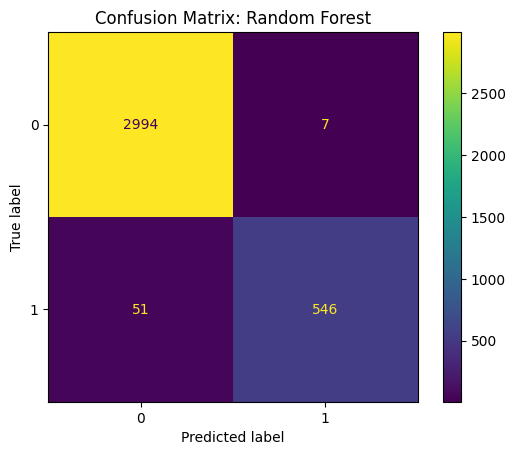


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3001
           1       0.99      0.91      0.95       597

    accuracy                           0.98      3598
   macro avg       0.99      0.96      0.97      3598
weighted avg       0.98      0.98      0.98      3598



In [25]:
from src.model_building import train_random_forest
from src.evaluation import plot_confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Train the model using our src function
rf_model = train_random_forest(X_train, y_train)

# 2. Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. Print Evaluation (matching your notebook's exact output)
print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

# 4. Show the Confusion Matrix
plot_confusion_matrix(rf_model, X_test, y_test, "Random Forest")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the processed DataFrame X
feature_names = X.columns

# Create a pandas Series for better visualization
importances_df = pd.Series(feature_importances, index=feature_names)

# Sort feature importances in descending order
importances_df = importances_df.sort_values(ascending=False)

# Display the top features
print("Top Feature Importances (Random Forest):")
print(importances_df.head(10))

Top Feature Importances (Random Forest):
satisfaction_level       0.268492
time_spend_company       0.227779
number_project           0.162598
average_monthly_hours    0.151379
last_evaluation          0.142466
work_accident            0.011246
salary_low               0.007497
department_sales         0.004651
salary_medium            0.004099
department_technical     0.003931
dtype: float64


/tmp/ipython-input-908806213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_df.head(10).values, y=importances_df.head(10).index, palette='viridis')


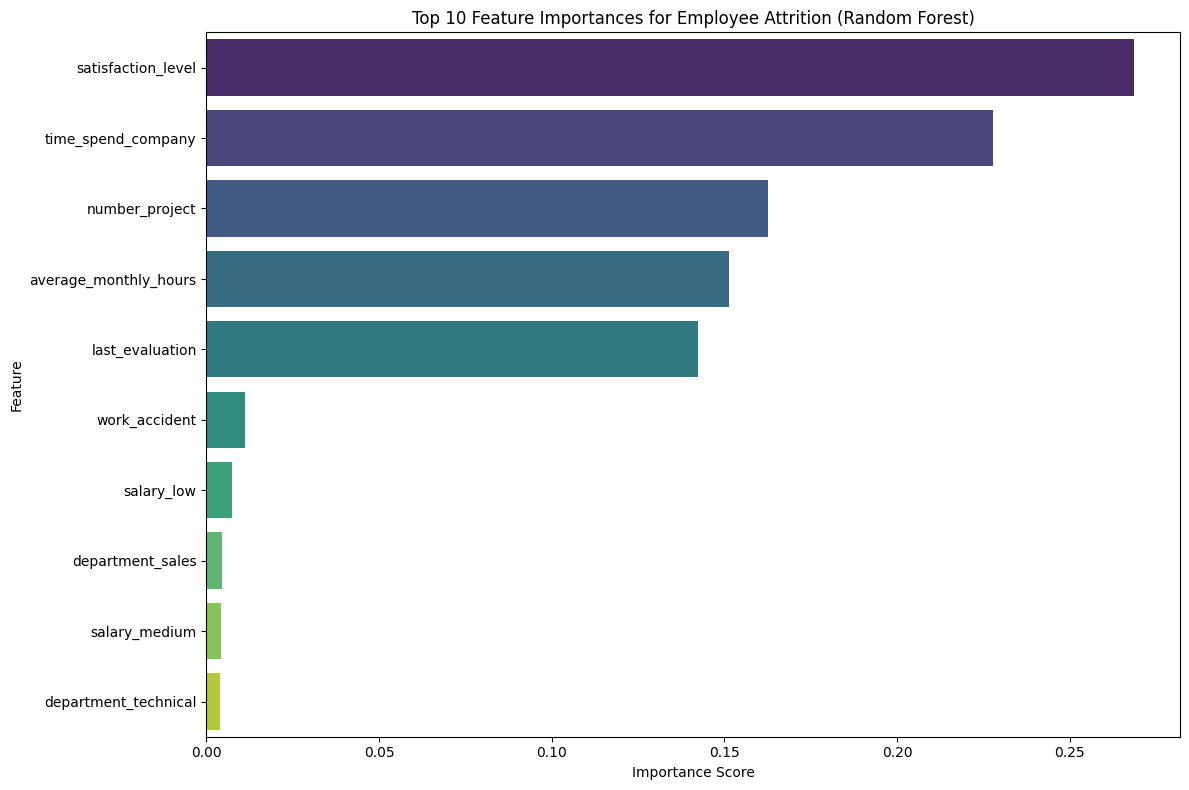

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=importances_df.head(10).values, y=importances_df.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances for Employee Attrition (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




## Identify High-Performing Leavers




**Reasoning**:
Filter the main DataFrame `df1` to identify high-performing employees who left and high-performing employees who stayed, based on the specified criteria for `left` and `last_evaluation`.



In [ ]:
high_performing_leavers = df1[(df1['left'] == 1) & (df1['last_evaluation'] >= 0.8)]
high_performing_stayers = df1[(df1['left'] == 0) & (df1['last_evaluation'] >= 0.8)]

print("High-Performing Leavers (first 5 rows):")
print(high_performing_leavers.head())
print(f"\nShape of High-Performing Leavers: {high_performing_leavers.shape}")

print("\nHigh-Performing Stayers (first 5 rows):")
print(high_performing_stayers.head())
print(f"\nShape of High-Performing Stayers: {high_performing_stayers.shape}")

High-Performing Leavers (first 5 rows):
   satisfaction_level  last_evaluation  number_project  average_monthly_hours  \
1                0.80             0.86               5                    262   
2                0.11             0.88               7                    272   
3                0.72             0.87               5                    223   
7                0.92             0.85               5                    259   
8                0.89             1.00               5                    224   

   time_spend_company  work_accident  left  promotion_last_5years department  \
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
7                   5              0     1                      0      sales   
8                   5              0     1                      0      sa

## Analyze Characteristics of High-Performing Leavers




**Reasoning**:
The subtask requires examining descriptive statistics for key numerical and categorical features for high-performing leavers and high-performing stayers. This step will calculate and display descriptive statistics for the specified numerical columns and value counts for the specified categorical columns for both groups.



In [ ]:
print("--- Descriptive Statistics for High-Performing Leavers ---")
print(high_performing_leavers[['satisfaction_level', 'number_project', 'average_monthly_hours', 'time_spend_company']].describe())

print("\nValue Counts for Salary (High-Performing Leavers):")
print(high_performing_leavers['salary'].value_counts(normalize=True) * 100)

print("\nValue Counts for Promotion Last 5 Years (High-Performing Leavers):")
print(high_performing_leavers['promotion_last_5years'].value_counts(normalize=True) * 100)


print("\n--- Descriptive Statistics for High-Performing Stayers ---")
print(high_performing_stayers[['satisfaction_level', 'number_project', 'average_monthly_hours', 'time_spend_company']].describe())

print("\nValue Counts for Salary (High-Performing Stayers):")
print(high_performing_stayers['salary'].value_counts(normalize=True) * 100)

print("\nValue Counts for Promotion Last 5 Years (High-Performing Stayers):")
print(high_performing_stayers['promotion_last_5years'].value_counts(normalize=True) * 100)


# Optional: Descriptive statistics for overall leavers (for context)
leavers_overall = df1[df1['left'] == 1]
print("\n--- Descriptive Statistics for Overall Leavers (for context) ---")
print(leavers_overall[['satisfaction_level', 'number_project', 'average_monthly_hours', 'time_spend_company']].describe())
print("\nValue Counts for Salary (Overall Leavers):")
print(leavers_overall['salary'].value_counts(normalize=True) * 100)
print("\nValue Counts for Promotion Last 5 Years (Overall Leavers):")
print(leavers_overall['promotion_last_5years'].value_counts(normalize=True) * 100)

--- Descriptive Statistics for High-Performing Leavers ---
       satisfaction_level  number_project  average_monthly_hours  \
count          988.000000      988.000000             988.000000   
mean             0.486660        5.280364             256.867409   
std              0.352736        1.058252              30.790129   
min              0.090000        2.000000             130.000000   
25%              0.100000        5.000000             242.000000   
50%              0.720000        5.000000             258.000000   
75%              0.820000        6.000000             275.000000   
max              0.920000        7.000000             310.000000   

       time_spend_company  
count          988.000000  
mean             4.615385  
std              0.753140  
min              2.000000  
25%              4.000000  
50%              5.000000  
75%              5.000000  
max              6.000000  

Value Counts for Salary (High-Performing Leavers):
salary
low       58.9068

**Reasoning**:
To visually compare the distribution of satisfaction levels between high-performing leavers and stayers, a kernel density estimate (KDE) plot will be used. This will highlight differences in their perceived job satisfaction.



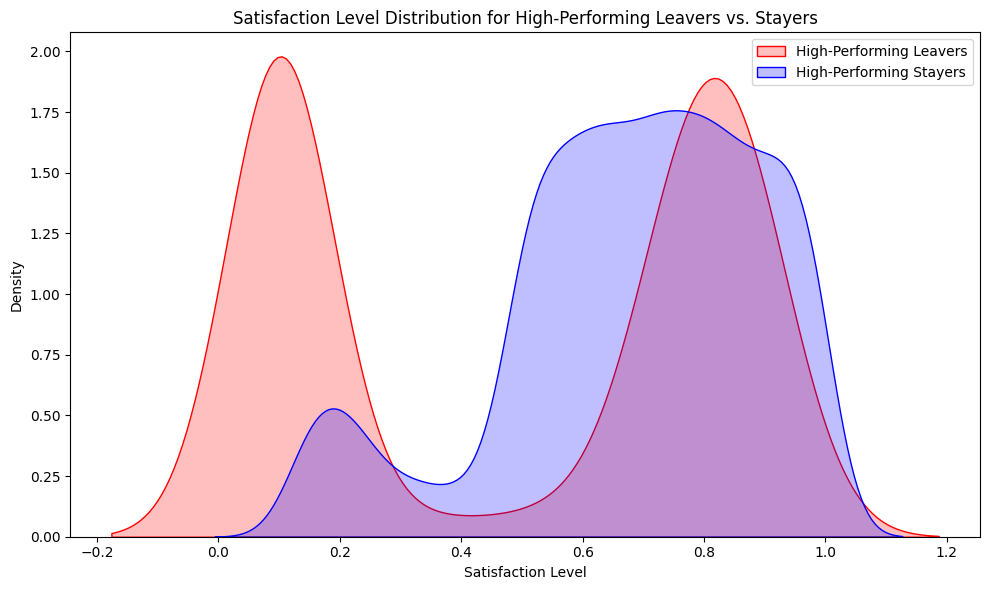

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='satisfaction_level', data=high_performing_leavers, fill=True, label='High-Performing Leavers', color='red')
sns.kdeplot(x='satisfaction_level', data=high_performing_stayers, fill=True, label='High-Performing Stayers', color='blue')
plt.title('Satisfaction Level Distribution for High-Performing Leavers vs. Stayers')
plt.xlabel('Satisfaction Level')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Visualize Key Factors for High-Performing Leavers



**Reasoning**:
To visualize and compare the distribution of 'salary' for high-performing leavers and stayers, I will create a combined DataFrame with a 'Group' column to distinguish between the two categories. Then, I will generate a countplot using this combined DataFrame.



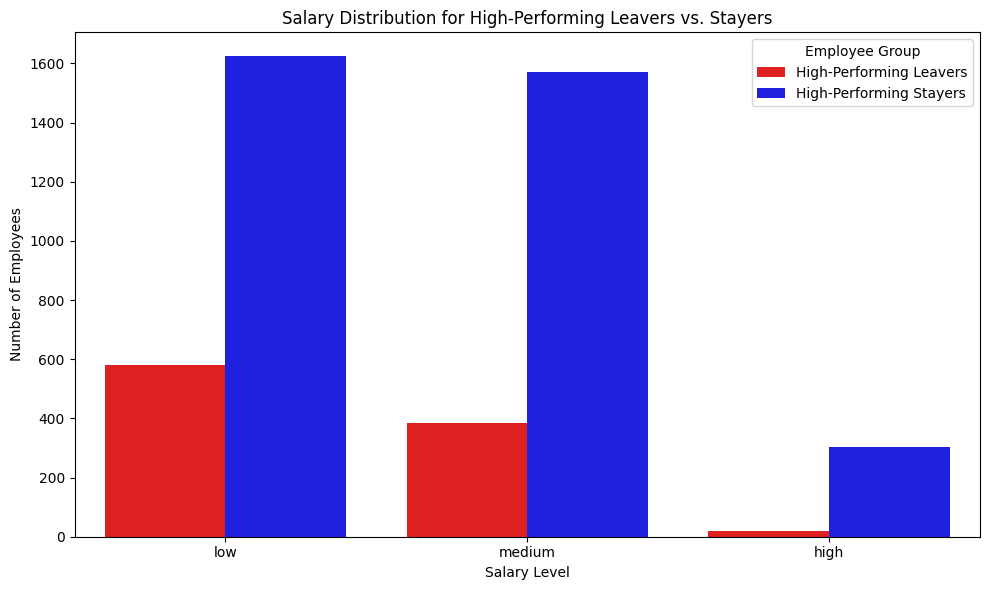

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'Group' column for high_performing_leavers
high_performing_leavers_plot = high_performing_leavers.copy()
high_performing_leavers_plot['Group'] = 'High-Performing Leavers'

# Create a 'Group' column for high_performing_stayers
high_performing_stayers_plot = high_performing_stayers.copy()
high_performing_stayers_plot['Group'] = 'High-Performing Stayers'

# Concatenate the two DataFrames for plotting
combined_high_performers = pd.concat([high_performing_leavers_plot, high_performing_stayers_plot])

plt.figure(figsize=(10, 6))
sns.countplot(x='salary', hue='Group', data=combined_high_performers, order=['low', 'medium', 'high'], palette={'High-Performing Leavers': 'red', 'High-Performing Stayers': 'blue'})
plt.title('Salary Distribution for High-Performing Leavers vs. Stayers')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(title='Employee Group')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize and compare the distribution of 'number_project' for high-performing leavers and stayers, I will use the `combined_high_performers` DataFrame and create a countplot, clearly labeling the axes and providing a legend for distinction between the groups.



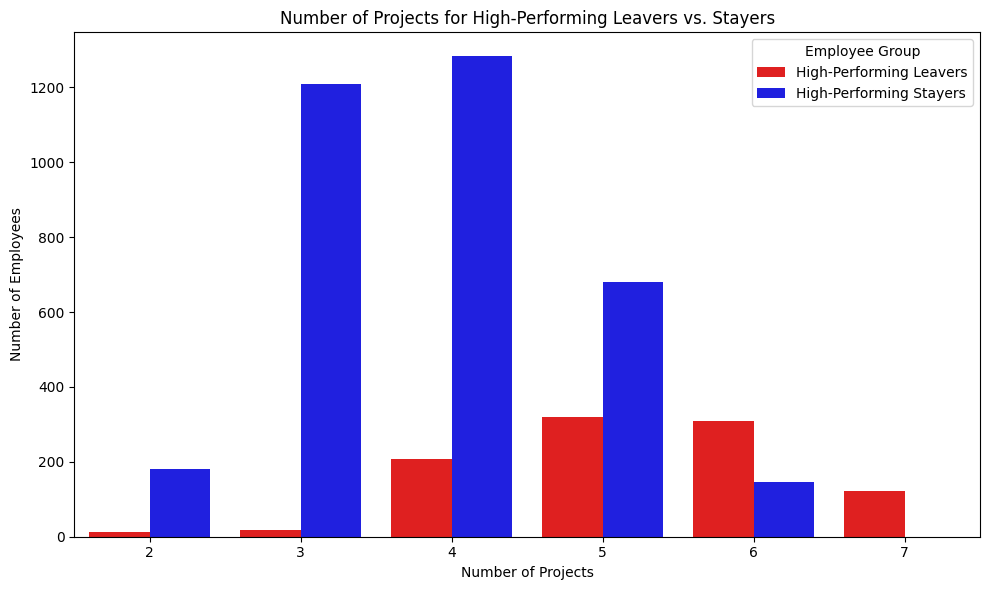

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='number_project', hue='Group', data=combined_high_performers, palette={'High-Performing Leavers': 'red', 'High-Performing Stayers': 'blue'})
plt.title('Number of Projects for High-Performing Leavers vs. Stayers')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.legend(title='Employee Group')
plt.tight_layout()
plt.show()

**Reasoning**:
To complete the visualization part of the subtask, I will create a Kernel Density Estimate (KDE) plot to compare the distribution of 'time_spend_company' for high-performing leavers and stayers, ensuring the plot has a title, axis labels, and a legend.



/tmp/ipython-input-1966980773.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Employee Group')


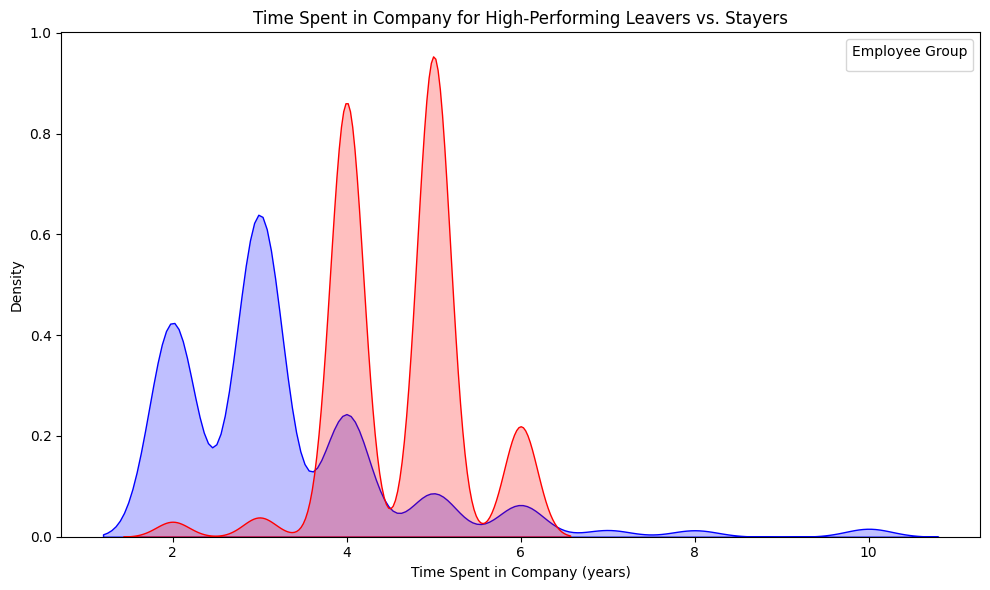

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='time_spend_company', hue='Group', data=combined_high_performers, fill=True, common_norm=False, palette={'High-Performing Leavers': 'red', 'High-Performing Stayers': 'blue'})
plt.title('Time Spent in Company for High-Performing Leavers vs. Stayers')
plt.xlabel('Time Spent in Company (years)')
plt.ylabel('Density')
plt.legend(title='Employee Group')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code produced a `UserWarning` because `plt.legend()` was called without explicit handles or labels, while `sns.kdeplot` with `hue` already creates its own legend. Removing the redundant `plt.legend()` call will allow seaborn to handle the legend correctly.



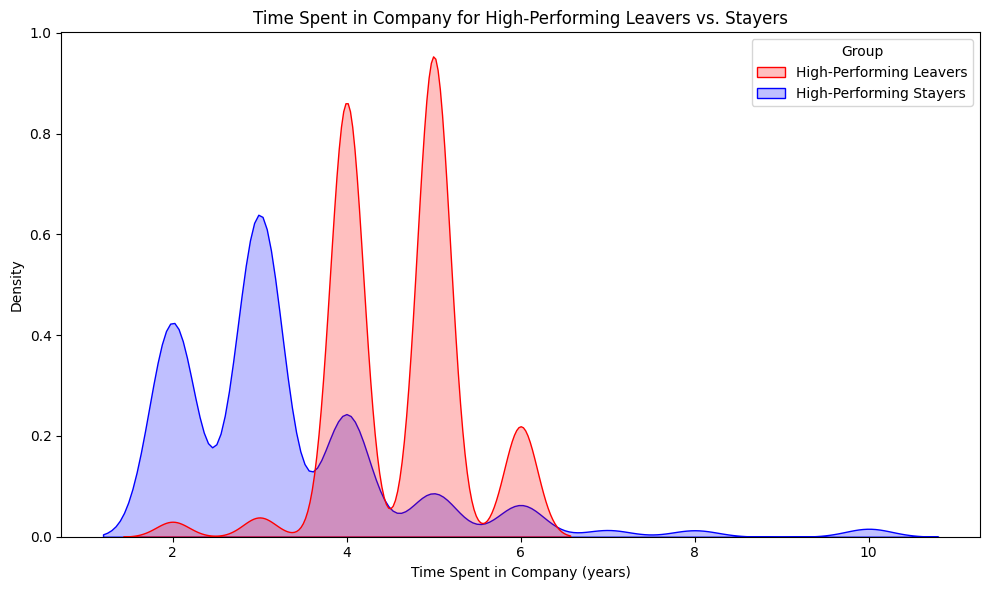

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='time_spend_company', hue='Group', data=combined_high_performers, fill=True, common_norm=False, palette={'High-Performing Leavers': 'red', 'High-Performing Stayers': 'blue'})
plt.title('Time Spent in Company for High-Performing Leavers vs. Stayers')
plt.xlabel('Time Spent in Company (years)')
plt.ylabel('Density')
# Removed plt.legend() as sns.kdeplot with hue automatically creates one
plt.tight_layout()
plt.show()

## Formulate Hypotheses and Recommendations




### Review of Descriptive Statistics and Visualizations

From the descriptive statistics and visualizations of high-performing leavers compared to high-performing stayers, several key differences and patterns emerge:

**1. Satisfaction Level:**
*   **High-Performing Leavers**: Show a bimodal distribution with peaks at very low satisfaction (around 0.1-0.2) and relatively high satisfaction (around 0.7-0.8). The initial insight from the overall dataset that high-performing leavers had high evaluation scores but low satisfaction is confirmed for a significant portion of this group.
*   **High-Performing Stayers**: Tend to have generally higher satisfaction levels, with a more concentrated distribution in the mid-to-high range.
*   **Insight**: A substantial number of high-performing leavers have very low satisfaction despite their high evaluation scores. This suggests a disconnect between their performance and their job satisfaction.

**2. Salary:**
*   **High-Performing Leavers**: A disproportionately high percentage (58.9%) are in the 'low' salary bracket, and 39% are 'medium'. Only a very small fraction (2.1%) are 'high' salary.
*   **High-Performing Stayers**: While a significant portion are also 'low' (46.4%), there's a more even distribution between 'low' and 'medium' salaries (44.9% medium), and a larger percentage (8.6%) in the 'high' salary bracket.
*   **Insight**: High-performing employees, especially those on lower salaries, are much more likely to leave. This strongly points to compensation as a critical factor.

**3. Number of Projects:**
*   **High-Performing Leavers**: Many have a very high number of projects (mean of 5.28, with 75% at 5 or 6 projects, and some at 7). There's a notable concentration around 5-7 projects.
*   **High-Performing Stayers**: Tend to have a more moderate number of projects (mean of 3.83, with 75% at 4 projects).
*   **Insight**: High-performing leavers are more frequently involved in a high number of projects, indicating potential overwork or burnout.

**4. Average Monthly Hours:**
*   **High-Performing Leavers**: Work significantly more hours on average (mean of 256.87 hours), with 75% working 275 hours or more. This aligns with the high number of projects.
*   **High-Performing Stayers**: Work a more standard number of hours (mean of 202.71 hours).
*   **Insight**: Excessive working hours are a strong indicator of departure for high-performing employees, further supporting the overwork/burnout hypothesis.

**5. Time Spent in Company:**
*   **High-Performing Leavers**: Show a concentration around 4-6 years, with the highest density around 5 years. This aligns with the overall attrition pattern observed earlier.
*   **High-Performing Stayers**: Show a broader distribution but with a peak at lower tenure (2-3 years) and fewer employees staying beyond 5-6 years in this high-performing group compared to leavers at those tenures.
*   **Insight**: The 4-6 year mark is critical for high-performing employees, suggesting a point where they might be seeking new challenges or better opportunities if not adequately recognized/compensated.

**6. Promotion Last 5 Years:**
*   **High-Performing Leavers**: Almost none (0.1%) received a promotion in the last 5 years.
*   **High-Performing Stayers**: A slightly higher, though still small, percentage (1.8%) received promotions.
*   **Insight**: Lack of career advancement opportunities is a significant driver for high-performing employees to leave, even more so than for overall leavers.


### Hypotheses and Targeted Recommendations

Based on the analysis of high-performing leavers, the following hypotheses and recommendations are proposed:

**Hypothesis 1: Inadequate Compensation for High Performance**
*   **Reasoning**: A large majority of high-performing leavers (58.9%) were in the 'low' salary bracket, significantly higher than high-performing stayers (46.4%). This suggests that despite their high performance, these employees felt undervalued or underpaid, leading them to seek better compensation elsewhere.
*   **Recommendation**:
    *   **Conduct a comprehensive compensation review**: Benchmark salaries for high-performing roles against industry standards to ensure competitive pay.
    *   **Implement performance-based bonuses/raises**: Establish clear criteria for salary increases and bonuses tied directly to performance evaluations, especially for top performers.
    *   **Proactive salary adjustments**: Review high-performers' salaries annually, even if they don't explicitly ask, to preemptively address potential dissatisfaction.

**Hypothesis 2: Overwork and Burnout**
*   **Reasoning**: High-performing leavers had a significantly higher number of projects (mean of 5.28 vs. 3.83 for stayers) and worked substantially more average monthly hours (256.87 vs. 202.71 for stayers). This indicates that their high performance might have come at the cost of excessive workload, leading to burnout and dissatisfaction.
*   **Recommendation**:
    *   **Workload management system**: Implement a system to track and balance workloads among high-performing employees to prevent over-allocation.
    *   **Promote work-life balance initiatives**: Encourage flexible working hours, remote work options, and mandatory time off to ensure employees can recharge.
    *   **Provide additional resources**: If high project counts are unavoidable, provide more support staff or tools to alleviate the burden on high-performing individuals.

**Hypothesis 3: Lack of Career Growth and Recognition**
*   **Reasoning**: An overwhelming 99.9% of high-performing leavers had not received a promotion in the last 5 years. This highlights a critical lack of career progression opportunities or recognition for their sustained high performance.
*   **Recommendation**:
    *   **Develop clear career paths**: Establish transparent career development frameworks for high-performing employees, outlining next steps and requirements for advancement.
    *   **Mentorship and leadership programs**: Offer opportunities for high-performers to mentor junior staff or participate in leadership development programs.
    *   **Regular performance feedback and recognition**: Beyond annual reviews, implement more frequent check-ins to discuss career aspirations and provide both formal and informal recognition for their contributions.
    *   **Succession planning**: Identify high-performing employees as potential successors for key roles and actively prepare them for these positions.

**Hypothesis 4: Dissatisfaction Beyond Compensation and Workload**
*   **Reasoning**: While many high-performing leavers had very low satisfaction, a notable portion also showed high satisfaction (0.7-0.8) just before leaving. This suggests that for some, the decision to leave might be driven by factors other than just pay or workload, such as company culture, management issues, or a desire for new challenges not available internally.
*   **Recommendation**:
    *   **Exit interviews with a focus on 'why'**: Conduct in-depth exit interviews for high-performing employees to uncover specific reasons for their departure, especially if they report high satisfaction.
    *   **Employee engagement surveys**: Implement regular, anonymous surveys to gauge sentiment on company culture, leadership effectiveness, and overall employee experience.
    *   **Stay interviews**: Proactively conduct 'stay interviews' with high-performing employees to understand what makes them stay, what challenges they face, and what might make them leave in the future.

## Summary:

### Q&A

**What were the key findings regarding high-performing employees who left, and what actionable recommendations can be provided to the HR department?**

The investigation revealed that high-performing employees who left the company often experienced a combination of low satisfaction despite high performance, inadequate compensation, excessive workload leading to burnout, and a significant lack of career growth and recognition. A substantial number (58.9%) of high-performing leavers were in the 'low' salary bracket, they worked significantly more hours (mean of 256.87 monthly hours) and managed more projects (mean of 5.28) compared to high-performing stayers, and a striking 99.9% had not received a promotion in the last five years.

Based on these findings, actionable recommendations for HR include: conducting a comprehensive compensation review and implementing performance-based bonuses, establishing a workload management system and promoting work-life balance initiatives, developing clear career paths with mentorship and leadership programs, and improving recognition and succession planning. Additionally, HR should conduct more in-depth exit interviews and "stay interviews" to uncover deeper drivers of dissatisfaction.

### Data Analysis Key Findings

*   **Prevalence of High-Performing Leavers**: 988 high-performing employees (those with `last_evaluation` \$\ge\$ 0.8) left the company, compared to 3498 high-performing employees who stayed.
*   **Low Satisfaction Despite High Performance**: High-performing leavers exhibited a bimodal distribution in `satisfaction_level`, with a significant portion having very low satisfaction (mean of 0.48, 25th percentile 0.10) even with high performance, in contrast to high-performing stayers (mean of 0.68).
*   **Inadequate Compensation**: A disproportionately high percentage of high-performing leavers (58.9%) were in the 'low' salary bracket, significantly more than high-performing stayers (46.4%).
*   **Excessive Workload**: High-performing leavers managed a higher average `number_project` (5.28) and worked substantially more `average_monthly_hours` (256.87) compared to high-performing stayers (3.83 projects and 202.71 monthly hours, respectively), indicating potential overwork.
*   **Lack of Career Advancement**: A striking 99.9% of high-performing leavers had not received a promotion in the last 5 years, highlighting a critical lack of recognition and growth opportunities.
*   **Critical Tenure Period**: High-performing leavers showed a concentration around 4-6 years of `time_spend_company`, suggesting this period is a critical point for potential departure.

### Insights or Next Steps

*   **Prioritize Compensation and Workload Review**: HR should immediately conduct an audit of compensation packages for high-performing employees to ensure they are competitive and implement strategies to manage and balance workloads to prevent burnout, given the strong correlation between these factors and departure.
*   **Enhance Career Development and Recognition**: Develop transparent career progression frameworks, offer mentorship and leadership development programs, and establish more frequent and meaningful recognition for high performers to address the observed lack of promotions and career growth opportunities.
